# Widget generation experiment — comparison charts

Self-contained visualization of the ZS/FS widget generation experiment across **four architectures**:
- **T1** direct widget (question → widget)
- **T2** text-mediated widget (question → text → widget)
- **T3** AXtree-mediated widget (question → real Chrome AXTree → script → widget)
- **T4** text-mediated AXtree (question → text → real Chrome AXTree → script → widget) ← t2-style architecture but with AXtree as the intermediate output

**Curation note:** earlier ablation runs used simplified-nested AXtree variants (`t3_full`, `t3_lean`). The final taxonomy uses only `t3_real` (renamed to **t3** in displays) and **t4** — both targeting the actual flat-with-parentId/childIds Chrome AXTree format.

**Temperature labels.** The data internally stores `'fixed'/'semi'/'random'`; this notebook relabels them as the actual temperatures used: **T=0**, **T=0.4**, **T=0.8**.

**Validity metric.** A single strict per-row check: did the model produce valid output in the format it was asked to generate?
- **t1, t2** — widget-level schema validity (model output IS the widget)
- **t3, t4** — AXtree-level integrity (broken refs, multiple parents, unknown roles, cycles, orphans)

The downstream adapter that converts AXtree → widget is permissive (it can recover some broken AXtrees into valid widgets), but we report validity *before* that recovery. What we measure is whether the model itself produced correct output, not whether a tool could fix it. The pipeline asymmetry — t1/t2 has one validation stage, t3/t4 has two — is itself part of the comparison: a shorter pipeline with fewer requirements is part of what t1/t2 brings.

**Layout:**
1. Setup and data load
2. Validity by condition
3. Few-shot effect on variance (structural + semantic)
4. Architectural divergence
5. Variance heatmap and temperature curve
6. Domain breakdown
7. Output characteristics (raw chars vs useful text)
8. Manual validation (subjective rating)
9. Key takeaways

## 1. Setup and data load

In [131]:
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path('.').resolve()
OUT = HERE / 'outputs'

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'axes.grid': True, 'axes.grid.axis': 'y', 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

COLORS = {
    't1/zs': '#3d5a80', 't1/fs': '#98c1d9',
    't2/zs': '#ee6c4d', 't2/fs': '#f4a261',
    't3/zs': '#6a4c93', 't3/fs': '#c8b6e2',
    't4/zs': '#2d8659', 't4/fs': '#94c9a9',
}
STATUS_COLORS = {'valid': '#4c9f70', 'soft_error': '#e0a458', 'hard_error': '#c14953'}
PAIR_COLORS = {
    't1_t2': '#6a4c93', 't1_t3': '#3a8e8e', 't1_t4': '#b85c00',
    't2_t3': '#c47a1f', 't2_t4': '#4d9999', 't3_t4': '#555555',
}

SEED_MODE_RENAME = {'fixed': 'T=0', 'semi': 'T=0.4', 'random': 'T=0.8'}
SM_ORDER = ['T=0', 'T=0.4', 'T=0.8']

KEEP_TYPES_RAW = {'t1', 't2', 't3_real', 't4'}
RENAME = {'t3_real': 't3'}
TYPE_ORDER = ['t1', 't2', 't3', 't4']

In [132]:
metrics_raw = [json.loads(l) for l in open(OUT / 'metrics.jsonl', encoding='utf-8') if l.strip()]
analysis = json.loads((OUT / 'analysis.json').read_text(encoding='utf-8'))
questions = {}
for line in open(HERE / 'eval_set' / 'questions.jsonl', encoding='utf-8'):
    if line.strip():
        r = json.loads(line)
        questions[r['id']] = r


# Useful text content: DFS-concat of 'name' string values from widget/AXtree.
# output_chars (in metrics.jsonl) counts JSON overhead too; this counts visible text only.
def _extract_text_content(s):
    if not s or not s.strip():
        return ''
    s = s.strip()
    if s.startswith('```'):
        i = s.find('\n')
        if i > 0:
            s = s[i + 1:]
    if s.endswith('```'):
        s = s[:-3].rstrip()
    try:
        obj = json.loads(s)
    except Exception:
        return ''
    names = []
    def walk(x):
        if isinstance(x, dict):
            n = x.get('name')
            if isinstance(n, str) and n.strip():
                names.append(n.strip())
            elif isinstance(n, dict):
                v = n.get('value')
                if isinstance(v, str) and v.strip():
                    names.append(v.strip())
            for k, v in x.items():
                if k != 'name':
                    walk(v)
        elif isinstance(x, list):
            for v in x:
                walk(v)
    walk(obj)
    return ' '.join(names)

text_chars_lookup = {}
with open(OUT / 'raw_outputs.jsonl', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue
        try:
            r = json.loads(line)
            key = (r['question_id'], r['type'], r['shots'], r['seed_mode'], r['run_idx'])
            text_chars_lookup[key] = len(_extract_text_content(r.get('output', '')))
        except Exception:
            continue
print(f'computed useful text_chars for {len(text_chars_lookup)} rows')


m = pd.DataFrame(metrics_raw)
m = m[m['type'].isin(KEEP_TYPES_RAW)].copy()
# Add text_chars BEFORE renames (lookup uses raw type/seed_mode keys)
m['text_chars'] = m.apply(
    lambda row: text_chars_lookup.get(
        (row['question_id'], row['type'], row['shots'], row['seed_mode'], row['run_idx']),
        0), axis=1)

m['type'] = m['type'].replace(RENAME)
m['seed_mode'] = m['seed_mode'].replace(SEED_MODE_RENAME)
m['domain'] = m['question_id'].map(lambda q: questions.get(q, {}).get('domain', '?'))

# Strict per-row validity (widget for t1/t2, axtree for t3/t4)
STATUS_MAP = {'valid': 'valid', 'soft_error': 'soft', 'hard_error': 'hard'}
mask_direct = m['type'].isin(['t1', 't2'])
m.loc[mask_direct, 'strict_status'] = m.loc[mask_direct, 'status'].map(STATUS_MAP)
m.loc[~mask_direct, 'strict_status'] = m.loc[~mask_direct, 'axtree_status']

per_condition_all = analysis['variance']['per_condition']
per_condition = [
    {**c, 'type': RENAME.get(c['type'], c['type']),
     'seed_mode': SEED_MODE_RENAME.get(c['seed_mode'], c['seed_mode'])}
    for c in per_condition_all if c['type'] in KEEP_TYPES_RAW
]

ALL_TYPE_NAMES = sorted({'t1', 't2', 't3', 't3_full', 't3_lean', 't3_real', 't4'},
                        key=len, reverse=True)
def split_pair(pair):
    for ta in ALL_TYPE_NAMES:
        if pair.startswith(ta + '_'):
            tb = pair[len(ta) + 1:]
            if tb in ALL_TYPE_NAMES:
                return ta, tb
    return pair, pair
type_pair_rows_all = analysis['cross_condition']['type_divergence_by_pair']
type_pair_rows = {}
for pair, rows in type_pair_rows_all.items():
    a, b = split_pair(pair)
    if a not in KEEP_TYPES_RAW or b not in KEEP_TYPES_RAW:
        continue
    new_a, new_b = RENAME.get(a, a), RENAME.get(b, b)
    if new_a > new_b:
        new_a, new_b = new_b, new_a
    type_pair_rows[f'{new_a}_{new_b}'] = [
        {**r, 'seed_mode': SEED_MODE_RENAME.get(r['seed_mode'], r['seed_mode'])}
        for r in rows
    ]

print(f"loaded {len(m)} metric rows  |  types: {sorted(m['type'].unique())}")
print(f"per_condition rows: {len(per_condition)} (expect 24 = 4 types × 2 shots × 3 temperatures)")
print(f"type pairs: {sorted(type_pair_rows.keys())}")
m.head(3)

computed useful text_chars for 2700 rows
loaded 1800 metric rows  |  types: ['t1', 't2', 't3', 't4']
per_condition rows: 24 (expect 24 = 4 types × 2 shots × 3 temperatures)
type pairs: ['t1_t2', 't1_t3', 't1_t4', 't2_t3', 't2_t4', 't3_t4']


,question_id,type,shots,seed_mode,run_idx,api_error,parse_strategy,status,axtree_status,axtree_issues,hard_error_msgs,norm_changes,node_count,max_depth,type_hist,hint_hist,output_chars,text_chars,domain,strict_status
0,q01,t1,zs,T=0,0,False,direct,soft_error,NaN,[],[],"[$.children[0]: filled missing children, $.chi...",22,4,"{'block': 6, 'text': 13, 'link': 3}","{'main': 1, 'vbox': 3, 'heading': 1, 'bold': 6...",3374,816,recommendation,soft
1,q01,t1,zs,T=0,1,False,direct,soft_error,NaN,[],[],"[$.children[0]: filled missing children, $.chi...",25,4,"{'block': 6, 'text': 13, 'image': 3, 'link': 3}","{'main': 1, 'vbox': 3, 'heading': 1, 'subheadi...",3780,892,recommendation,soft
2,q01,t1,zs,T=0,2,False,direct,soft_error,NaN,[],[],"[$.children[0]: filled missing children, $.chi...",22,4,"{'block': 6, 'text': 13, 'link': 3}","{'main': 1, 'vbox': 3, 'heading': 1, 'bold': 6...",3427,869,recommendation,soft


## 2. Validity by condition

A single strict per-row metric: did the model produce valid output in its requested format?

- **t1, t2**: widget schema validity (model output IS the widget; no adapter)
- **t3, t4**: AXtree integrity (broken refs, multiple parents, unknown roles, cycles, orphans). The downstream permissive adapter often masks these by recovering them into a valid widget — we ignore that recovery here, because validity is a claim about the *model*, not the recovery tool.

Three tiers: **valid** (passes as-is), **soft** (recoverable via normalization), **hard** (genuine format failure or unparseable JSON).

The pipeline asymmetry is intentional: t1/t2 have one validation stage, t3/t4 have two. A shorter pipeline being subject to fewer requirements is part of the architectural advantage of direct generation, not a methodological problem.

In [133]:
def validity_summary(df, status_col='strict_status'):
    rows = []
    for (typ, shots), grp in df.groupby(['type', 'shots']):
        n = len(grp)
        c = grp[status_col].value_counts()
        rows.append({
            'condition': f'{typ}/{shots}',
            'valid': int(c.get('valid', 0)),
            'soft':  int(c.get('soft', 0)),
            'hard':  int(c.get('hard', 0)),
            'n': n,
            '% valid': round(100 * c.get('valid', 0) / n, 1),
        })
    return pd.DataFrame(rows).sort_values('condition').reset_index(drop=True)

v_valid = validity_summary(m)
v_valid

,condition,valid,soft,hard,n,% valid
0,t1/fs,220,0,5,225,97.8
1,t1/zs,122,101,2,225,54.2
2,t2/fs,225,0,0,225,100.0
3,t2/zs,131,94,0,225,58.2
4,t3/fs,79,136,10,225,35.1
5,t3/zs,174,44,7,225,77.3
6,t4/fs,77,97,51,225,34.2
7,t4/zs,103,67,55,225,45.8


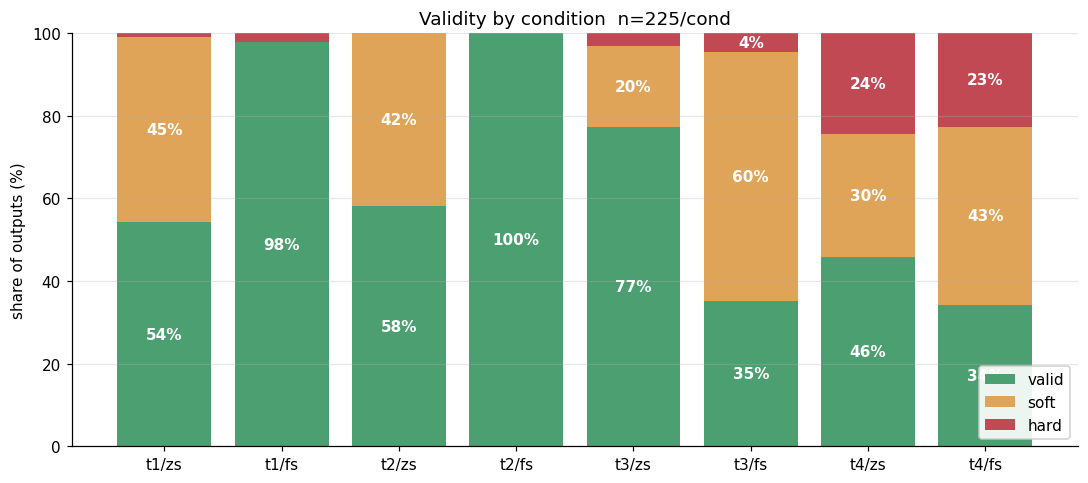

In [134]:
order = [f'{t}/{s}' for t in TYPE_ORDER for s in ['zs', 'fs']]
v_o = v_valid.set_index('condition').reindex(order)

fig, ax = plt.subplots(figsize=(10, 4.5))
bottom = np.zeros(len(order))
for st_lbl in ['valid', 'soft', 'hard']:
    vals = 100 * v_o[st_lbl].values / v_o['n'].values
    color_key = {'valid': 'valid', 'soft': 'soft_error', 'hard': 'hard_error'}[st_lbl]
    ax.bar(order, vals, bottom=bottom, label=st_lbl, color=STATUS_COLORS[color_key])
    for i, (b, vv) in enumerate(zip(bottom, vals)):
        if vv > 4:
            ax.text(i, b + vv / 2, f'{vv:.0f}%', ha='center', va='center',
                    color='white', fontsize=10, fontweight='bold')
    bottom += vals
ax.set_ylim(0, 100)
ax.set_ylabel('share of outputs (%)')
ax.set_title(f'Validity by condition  n={int(v_o["n"].iloc[0])}/cond')
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig(OUT / 'charts' / '01_validity_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Few-shot effect on variance — structural AND semantic in parallel

Two parallel metrics: **structural** (normalized tree edit distance) and **semantic** (1 − cosine similarity of text embeddings). Across all four architectures, few-shot reduces structural variance ~25-40%.

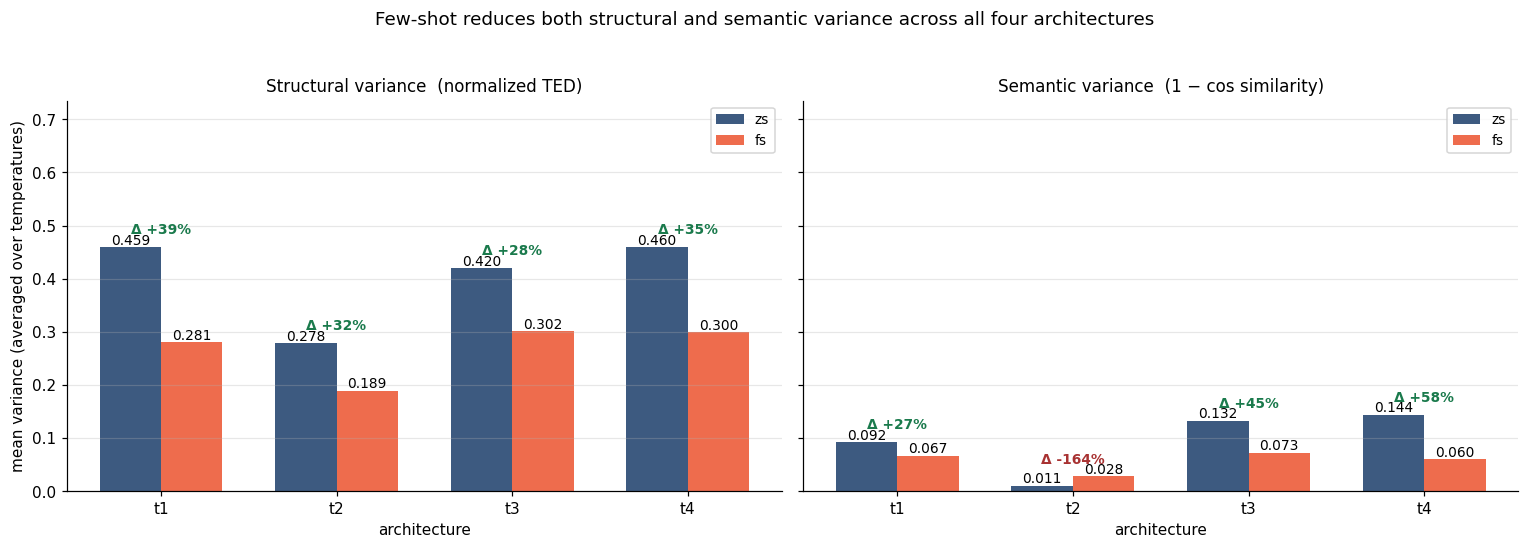


Structural / semantic variance ratio per architecture (avg over shots × T):
   t1: struct=0.370 seman=0.080 ratio=4.7× — content stable, structure varies
   t2: struct=0.234 seman=0.019 ratio=12.2× — content stable, structure varies
   t3: struct=0.361 seman=0.103 ratio=3.5× — content stable, structure varies
   t4: struct=0.380 seman=0.102 ratio=3.7× — content stable, structure varies


In [135]:
pc = pd.DataFrame(per_condition)
pivot_struct = pc.pivot_table(index=['type', 'shots'], columns='seed_mode',
                               values='mean_structural_variance')[SM_ORDER]
pivot_seman = pc.pivot_table(index=['type', 'shots'], columns='seed_mode',
                              values='mean_semantic_variance')[SM_ORDER]
pivot = pivot_struct

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
x = np.arange(len(TYPE_ORDER))
width = 0.35

for ax, this_pivot, ttl in [
    (axes[0], pivot_struct, 'Structural variance  (normalized TED)'),
    (axes[1], pivot_seman, 'Semantic variance  (1 − cos similarity)'),
]:
    for i, s in enumerate(['zs', 'fs']):
        vals = [this_pivot.loc[(t, s)].mean() if (t, s) in this_pivot.index else 0.0
                for t in TYPE_ORDER]
        ax.bar(x + (i - 0.5) * width, vals, width, label=s,
               color='#3d5a80' if s == 'zs' else '#ee6c4d')
        for j, val in enumerate(vals):
            ax.text(x[j] + (i - 0.5) * width, val + 0.005, f'{val:.3f}',
                    ha='center', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(TYPE_ORDER)
    ax.set_xlabel('architecture')
    ax.set_title(ttl, fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    for i, t in enumerate(TYPE_ORDER):
        zs_v = this_pivot.loc[(t, 'zs')].mean() if (t, 'zs') in this_pivot.index else 0
        fs_v = this_pivot.loc[(t, 'fs')].mean() if (t, 'fs') in this_pivot.index else 0
        if zs_v > 0:
            delta = 100 * (zs_v - fs_v) / zs_v
            ax.text(i, max(zs_v, fs_v) + 0.025, f'Δ {delta:+.0f}%',
                    ha='center', fontsize=9, fontweight='bold',
                    color='#1a7a4c' if delta > 0 else '#a83232')

axes[0].set_ylabel('mean variance (averaged over temperatures)')
ymax = pivot_struct.values.max() * 1.18
axes[0].set_ylim(0, ymax)
fig.suptitle('Few-shot reduces both structural and semantic variance across all four architectures',
             y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(OUT / 'charts' / '02_few_shot_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nStructural / semantic variance ratio per architecture (avg over shots × T):')
for t in TYPE_ORDER:
    s = pivot_struct.loc[t].values.mean()
    m_ = pivot_seman.loc[t].values.mean()
    print(f'   {t}: struct={s:.3f} seman={m_:.3f} ratio={s / m_:.1f}× — content stable, structure varies')

## 4. Architectural divergence

For each pair of architectures, mean structural distance between outputs (averaged across all 25 questions). With 4 types we get 6 pairs.

In [136]:
wtv = {t: pc[pc['type'] == t]['mean_structural_variance'].mean() for t in TYPE_ORDER}

rows = []
for pair, prows in sorted(type_pair_rows.items()):
    a, b = split_pair(pair)
    a_var, b_var = wtv.get(a), wtv.get(b)
    struct_div = np.mean([r['structural_divergence'] for r in prows if r['structural_divergence'] is not None])
    seman_div = np.mean([r['semantic_divergence'] for r in prows if r['semantic_divergence'] is not None])
    noise = max(a_var, b_var)
    rows.append({
        'pair': f'{a} vs {b}',
        'struct divergence': round(struct_div, 3),
        'seman divergence': round(seman_div, 3),
        f'within-var {a}': round(a_var, 3),
        f'within-var {b}': round(b_var, 3),
        'div > noise?': 'YES' if struct_div > noise else 'no',
    })
pd.DataFrame(rows)

,pair,struct divergence,seman divergence,within-var t1,within-var t2,div > noise?,within-var t3,within-var t4
0,t1 vs t2,0.656,0.137,0.37,0.234,YES,NaN,NaN
1,t1 vs t3,0.842,0.140,0.37,NaN,YES,0.361,NaN
2,t1 vs t4,0.847,0.164,0.37,NaN,YES,NaN,0.38
3,t2 vs t3,0.886,0.187,NaN,0.234,YES,0.361,NaN
4,t2 vs t4,0.789,0.111,NaN,0.234,YES,NaN,0.38
5,t3 vs t4,0.617,0.192,NaN,NaN,YES,0.361,0.38


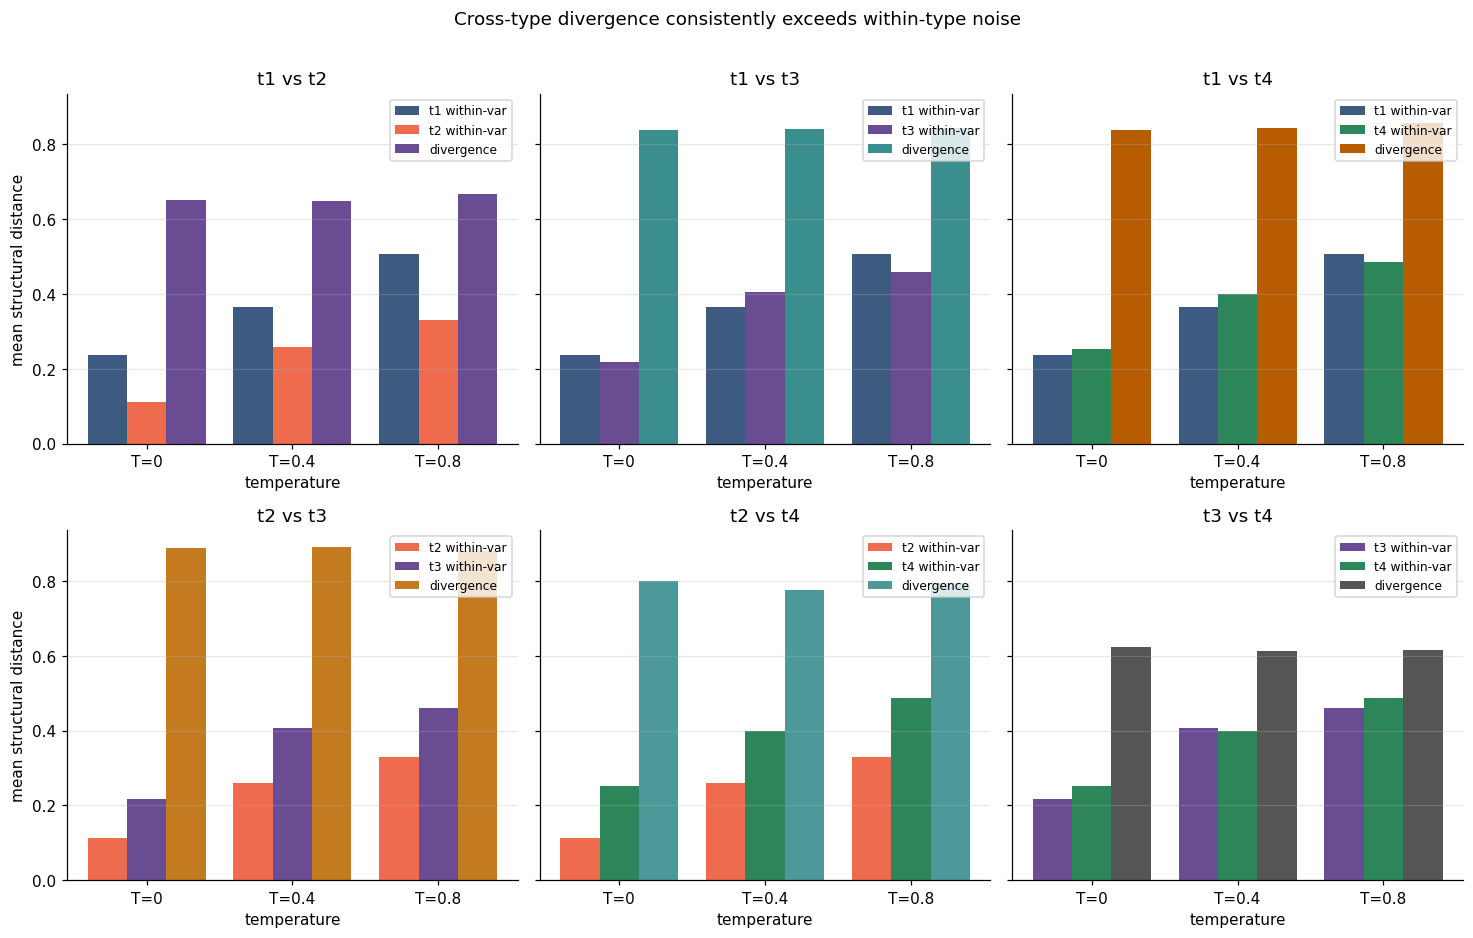

In [137]:
pairs = sorted(type_pair_rows.keys())
n_pairs = len(pairs)
ncols = 3
nrows = (n_pairs + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.2 * nrows), sharey=True)
axes_flat = axes.flatten() if nrows > 1 else axes
for idx, pair in enumerate(pairs):
    ax = axes_flat[idx]
    a, b = split_pair(pair)
    div_by_sm = defaultdict(list)
    for r in type_pair_rows[pair]:
        if r['structural_divergence'] is not None:
            div_by_sm[r['seed_mode']].append(r['structural_divergence'])
    a_v = [(pivot.loc[(a, 'zs')][sm] + pivot.loc[(a, 'fs')][sm]) / 2 for sm in SM_ORDER]
    b_v = [(pivot.loc[(b, 'zs')][sm] + pivot.loc[(b, 'fs')][sm]) / 2 for sm in SM_ORDER]
    div = [np.mean(div_by_sm[sm]) if div_by_sm[sm] else 0 for sm in SM_ORDER]
    xs = np.arange(3); ww = 0.27
    ax.bar(xs - ww, a_v, ww, label=f'{a} within-var', color=COLORS[f'{a}/zs'])
    ax.bar(xs, b_v, ww, label=f'{b} within-var', color=COLORS[f'{b}/zs'])
    ax.bar(xs + ww, div, ww, label='divergence', color=PAIR_COLORS.get(pair, '#444'))
    ax.set_xticks(xs); ax.set_xticklabels(SM_ORDER)
    ax.set_title(f'{a} vs {b}')
    ax.set_xlabel('temperature')
    ax.legend(fontsize=8)
for k in range(n_pairs, len(axes_flat)):
    axes_flat[k].set_visible(False)
for ax_row in axes if nrows > 1 else [axes]:
    (ax_row[0] if nrows > 1 else ax_row).set_ylabel('mean structural distance')
fig.suptitle('Cross-type divergence consistently exceeds within-type noise', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 5. Variance heatmap and temperature curve

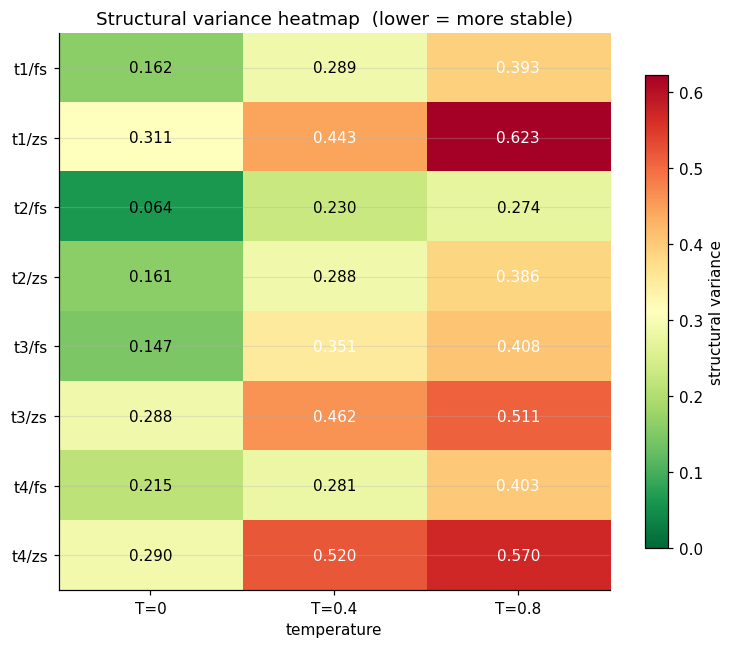

In [138]:
fig, ax = plt.subplots(figsize=(7, 6))
vmax = pivot.values.max()
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=vmax)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{t}/{s}' for t, s in pivot.index])
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                color='white' if val > vmax * 0.55 else 'black', fontsize=10)
ax.set_xlabel('temperature')
ax.set_title('Structural variance heatmap  (lower = more stable)')
fig.colorbar(im, ax=ax, label='structural variance', shrink=0.85)
plt.tight_layout()
plt.show()

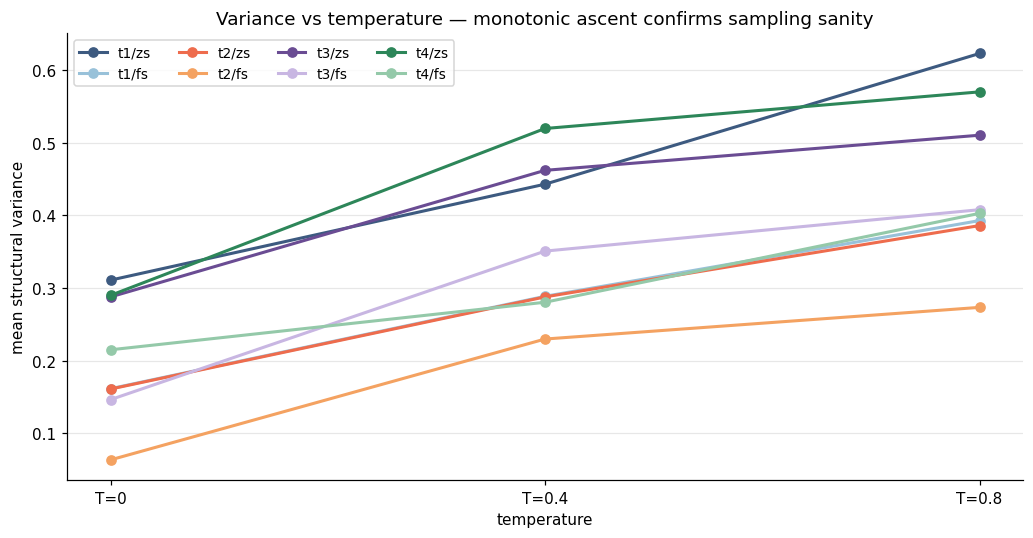

In [139]:
fig, ax = plt.subplots(figsize=(9.5, 5))
for t in TYPE_ORDER:
    for s in ['zs', 'fs']:
        if (t, s) in pivot.index:
            ax.plot(SM_ORDER, pivot.loc[(t, s)].values, marker='o',
                    linewidth=2, label=f'{t}/{s}', color=COLORS[f'{t}/{s}'])
ax.set_xlabel('temperature')
ax.set_ylabel('mean structural variance')
ax.set_title('Variance vs temperature — monotonic ascent confirms sampling sanity')
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

## 6. Domain breakdown

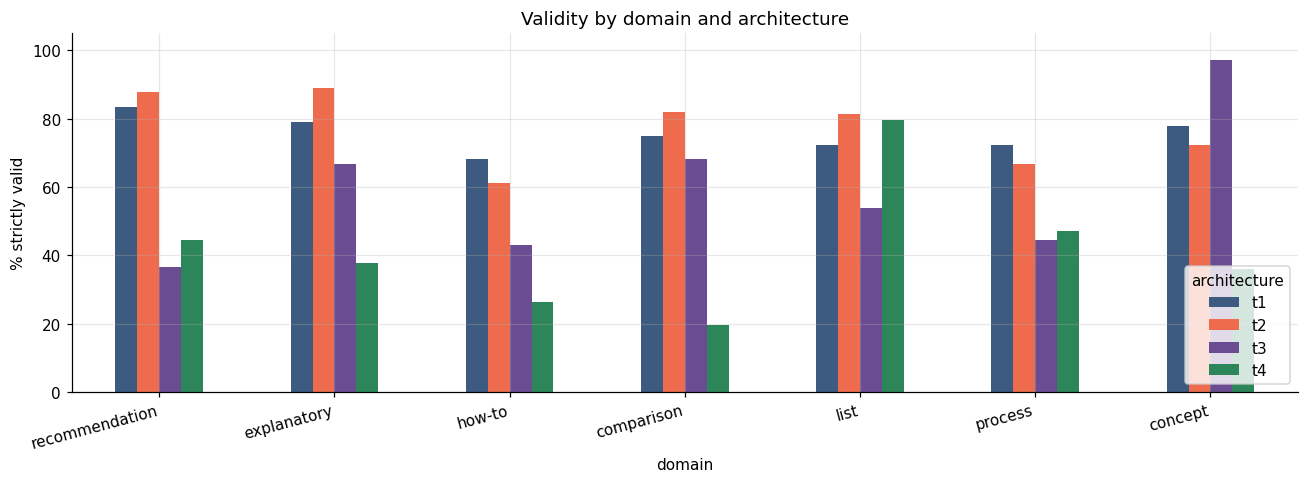

In [140]:
dom_v = m.groupby(['domain', 'type']).apply(
    lambda g: 100 * (g['strict_status'] == 'valid').sum() / len(g)).unstack()
dom_order = ['recommendation', 'explanatory', 'how-to', 'comparison', 'list', 'process', 'concept']
dom_v = dom_v.reindex([d for d in dom_order if d in dom_v.index])
dom_v = dom_v[[t for t in TYPE_ORDER if t in dom_v.columns]]

ax = dom_v.plot(kind='bar', figsize=(12, 4.5),
                color=[COLORS.get(f'{t}/zs', '#999') for t in dom_v.columns])
ax.set_ylabel('% strictly valid')
ax.set_title('Validity by domain and architecture')
ax.set_ylim(0, 105)
ax.legend(title='architecture', loc='lower right')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 7. Output characteristics

Two char-count metrics:
- **raw_chars** = total characters of the model's output string (includes all JSON syntax, field names, brackets, escapes — what the model is billed for and what fills its context)
- **text_chars** = sum of lengths of all visible-text `name` fields after DFS walk (what a user actually reads)

Ratio text/raw shows JSON overhead per architecture: high ratio = tight output (mostly content), low ratio = lots of structural overhead (especially relevant for AXtree-format t3/t4 which has verbose role-typed nodes).

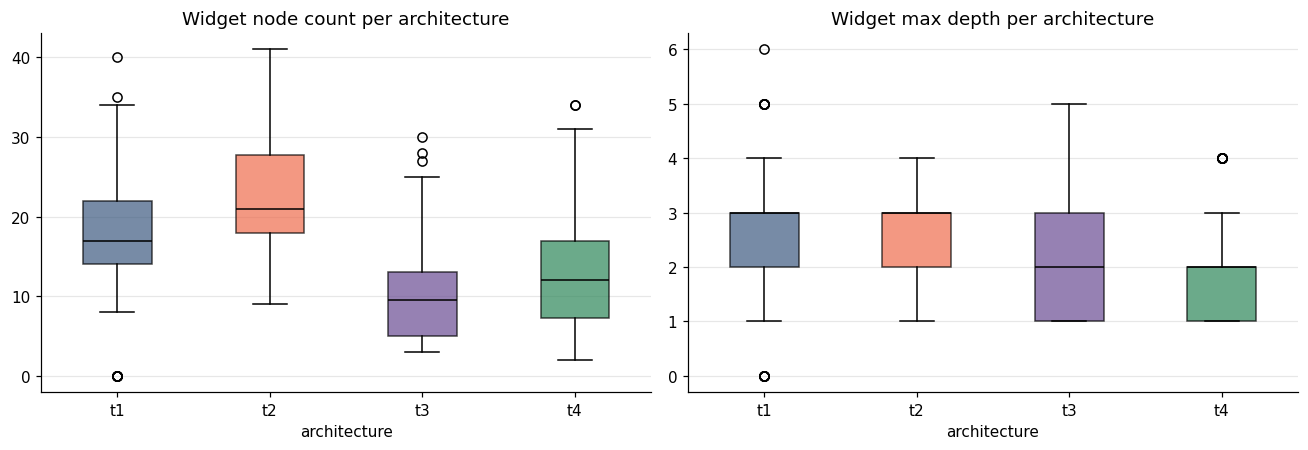


Output size per condition — raw_chars vs useful text_chars:
condition          avg raw    avg text  text/raw   avg nodes
------------------------------------------------------------
t1/zs                 3392         832    24.5%        21.3
t1/fs                 1682         725    43.1%        14.6
t2/zs                 4962        2304    46.4%        22.7
t2/fs                 3152        1601    50.8%        23.0
t3/zs                 3351         594    17.7%         7.1
t3/fs                 4366         760    17.4%        11.9
t4/zs                 6054        2129    35.2%         9.7
t4/fs                 6137        1478    24.1%        15.3


In [141]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, key, ttl in zip(axes, ['node_count', 'max_depth'], ['Widget node count', 'Widget max depth']):
    data = [m[m['type'] == t][key].values for t in TYPE_ORDER]
    bp = ax.boxplot(data, tick_labels=TYPE_ORDER, patch_artist=True,
                    medianprops=dict(color='black'))
    for patch, t in zip(bp['boxes'], TYPE_ORDER):
        patch.set_facecolor(COLORS[f'{t}/zs'])
        patch.set_alpha(0.7)
    ax.set_title(f'{ttl} per architecture')
    ax.set_xlabel('architecture')
plt.tight_layout()
plt.show()

print('\nOutput size per condition — raw_chars vs useful text_chars:')
print(f"{'condition':<14}{'avg raw':>12}{'avg text':>12}{'text/raw':>10}{'avg nodes':>12}")
print('-' * 60)
for t in TYPE_ORDER:
    for s in ['zs', 'fs']:
        sub = m[(m['type'] == t) & (m['shots'] == s)]
        if len(sub):
            raw = sub['output_chars'].mean()
            txt = sub['text_chars'].mean()
            ratio = txt / raw if raw else 0
            print(f'{t + "/" + s:<14}{raw:>12.0f}{txt:>12.0f}{ratio:>9.1%}{sub["node_count"].mean():>12.1f}')

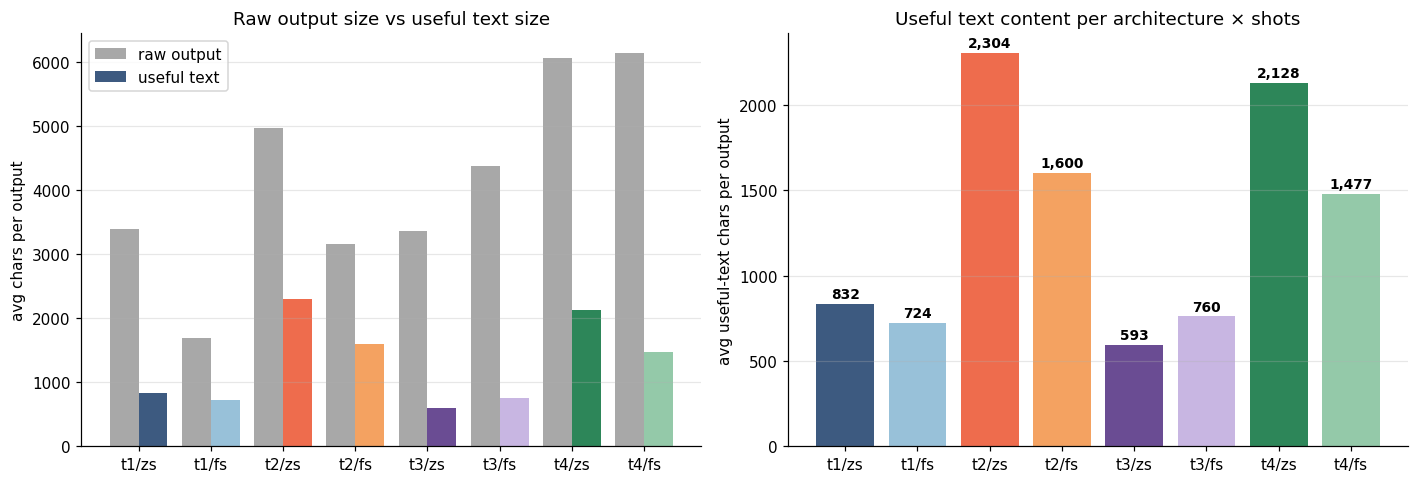


Parse strategy breakdown:
parse_strategy  direct  fenced  unparseable
row_0                                      
t1/zs              225       0            0
t1/fs              220       0            5
t2/zs               34     191            0
t2/fs              225       0            0
t3/zs              225       0            0
t3/fs              225       0            0
t4/zs              225       0            0
t4/fs              225       0            0


In [142]:
# Visual: avg text_chars vs avg raw_chars per condition
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
chars_by_cond = m.groupby(['type', 'shots']).agg(
    raw=('output_chars', 'mean'),
    text=('text_chars', 'mean'),
).reindex([(t, s) for t in TYPE_ORDER for s in ['zs', 'fs']])

# Left: raw vs text bars
ax = axes[0]
x = np.arange(len(order))
w = 0.4
ax.bar(x - w/2, chars_by_cond['raw'].values, w, label='raw output',
       color='#999', alpha=0.85)
ax.bar(x + w/2, chars_by_cond['text'].values, w, label='useful text',
       color=[COLORS[c] for c in order])
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel('avg chars per output')
ax.set_title('Raw output size vs useful text size')
ax.legend()

# Right: useful text only — emphasises the content-volume comparison
ax = axes[1]
ax.bar(order, chars_by_cond['text'].values, color=[COLORS[c] for c in order])
ax.set_ylabel('avg useful-text chars per output')
ax.set_title('Useful text content per architecture × shots')
for i, v in enumerate(chars_by_cond['text'].values):
    ax.text(i, v + chars_by_cond['text'].max() * 0.015,
            f'{int(v):,}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'charts' / '03_content_density.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nParse strategy breakdown:')
strat = pd.crosstab(m['type'] + '/' + m['shots'], m['parse_strategy'])
strat = strat[[c for c in ['direct', 'fenced', 'substring', 'unparseable', 'empty'] if c in strat.columns]]
strat = strat.reindex(order)
print(strat)

## 8. Manual validation

5 ratings per (type × shots) condition × 8 conditions = 40 cards. Rated on 1-5 Likert scale by one rater, blind to condition (shuffled order, reveal disabled until export).

**Anchors:** 1 = broken / unusable · 2 = correct content but poorly structured · 3 = ok with some flaws · 4 = good, minor issues · 5 = excellent.

This is a small-sample qualitative validation of automatic metrics — not a formal statistical study (N=5/condition gives high sampling noise). The goal: see whether automatic validity rankings align with human judgment, and surface failure modes that automatic metrics miss.

In [143]:
from scipy import stats as _stats

ratings_df = pd.read_csv(OUT / 'manual_ratings.csv')
ratings_df['type'] = ratings_df['type'].replace({'t3_real': 't3'})
ratings_df['cond'] = ratings_df['type'] + '/' + ratings_df['shots']

manual_agg = (
    ratings_df.groupby('cond')
    .agg(n=('rating', 'count'),
         mean=('rating', 'mean'),
         std=('rating', 'std'),
         med=('rating', 'median'))
    .reindex(order)
    .round(2)
)
print(f'loaded {len(ratings_df)} ratings  |  {ratings_df["rating"].notna().sum()} non-null')
manual_agg

loaded 40 ratings  |  40 non-null


,n,mean,std,med
cond,,,,
t1/zs,5,4.8,0.45,5.0
t1/fs,5,3.4,0.89,4.0
t2/zs,5,4.8,0.45,5.0
t2/fs,5,4.8,0.45,5.0
t3/zs,5,1.8,1.10,1.0
t3/fs,5,2.4,0.55,2.0
t4/zs,5,2.6,1.52,3.0
t4/fs,5,3.0,0.71,3.0


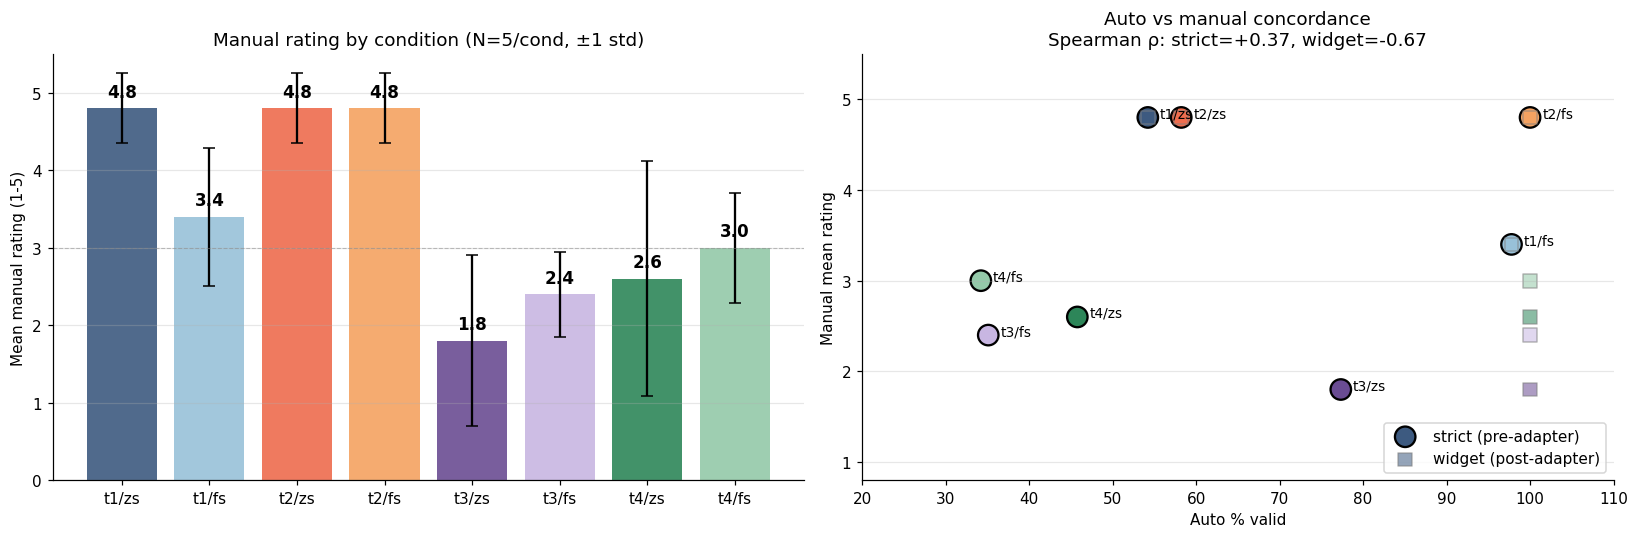


Spearman rank correlations (n=8 conditions):
  widget-level vs manual: ρ = -0.671  (p = 0.069)  -- post-adapter
  strict-level  vs manual: ρ = +0.366  (p = 0.373)  -- pre-adapter

Interpretation: the positive shift from widget-Spearman to strict-Spearman
shows manual rating sees through the permissive adapter, which empirically
supports reporting strict (pre-adapter) validity as the headline metric.


In [144]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) mean rating per condition with std errorbars
ax = axes[0]
means = manual_agg['mean'].values
stds = manual_agg['std'].values
ax.bar(order, means, yerr=stds, capsize=4,
       color=[COLORS[c] for c in order], alpha=0.9)
ax.set_ylabel('Mean manual rating (1-5)')
ax.set_title(f'Manual rating by condition (N={int(manual_agg["n"].iloc[0])}/cond, ±1 std)')
ax.set_ylim(0, 5.5)
ax.axhline(3, ls='--', color='#888', lw=0.7, alpha=0.5)
for i, mv in enumerate(means):
    if not np.isnan(mv):
        ax.text(i, mv + 0.15, f'{mv:.1f}', ha='center', fontsize=11, fontweight='bold')

# (b) auto strict %valid vs manual mean — Spearman scatter
ax = axes[1]
strict_pct = []
widget_pct = []
for cond in order:
    t, s = cond.split('/')
    sub = m[(m['type'] == t) & (m['shots'] == s)]
    strict_pct.append((sub['strict_status'] == 'valid').mean() * 100)
    widget_pct.append((sub['status'] == 'valid').mean() * 100)
strict_pct = np.array(strict_pct)
widget_pct = np.array(widget_pct)

ax.scatter(strict_pct, means, s=180, c=[COLORS[c] for c in order],
           edgecolors='black', linewidth=1.5, label='strict (pre-adapter)')
ax.scatter(widget_pct, means, s=80, c=[COLORS[c] for c in order],
           edgecolors='gray', linewidth=1, alpha=0.55, marker='s',
           label='widget (post-adapter)')
for i, cond in enumerate(order):
    ax.annotate(cond, (strict_pct[i], means[i]), xytext=(8, 0),
                textcoords='offset points', fontsize=9)
rho_s, p_s = _stats.spearmanr(strict_pct, means)
rho_w, p_w = _stats.spearmanr(widget_pct, means)
ax.set_xlabel('Auto % valid')
ax.set_ylabel('Manual mean rating')
ax.set_title(f'Auto vs manual concordance\nSpearman ρ: strict={rho_s:+.2f}, widget={rho_w:+.2f}')
ax.set_xlim(20, 110)
ax.set_ylim(0.8, 5.5)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUT / 'charts' / '04_manual_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSpearman rank correlations (n=8 conditions):')
print(f'  widget-level vs manual: ρ = {rho_w:+.3f}  (p = {p_w:.3f})  -- post-adapter')
print(f'  strict-level  vs manual: ρ = {rho_s:+.3f}  (p = {p_s:.3f})  -- pre-adapter')
print()
print('Interpretation: the positive shift from widget-Spearman to strict-Spearman')
print('shows manual rating sees through the permissive adapter, which empirically')
print('supports reporting strict (pre-adapter) validity as the headline metric.')

## 9. Key takeaways

In [145]:
vt = v_valid.set_index('condition')

print('=' * 72)
print('KEY TAKEAWAYS')
print('=' * 72)
print()
print('1. STRICT VALIDITY  (model output in requested format, pre-adapter)')
print(f'   {"condition":<10}{"valid":>10}{"soft":>8}{"hard":>8}{"% valid":>12}')
print('-' * 50)
for c in order:
    r = vt.loc[c]
    print(f'   {c:<10}{int(r["valid"]):>10}{int(r["soft"]):>8}{int(r["hard"]):>8}{r["% valid"]:>11.1f}%')
print()
t1_zs = vt.loc['t1/zs', '% valid']; t1_fs = vt.loc['t1/fs', '% valid']
print('   Architectural gaps vs t1 baselines:')
for c in ['t3/zs','t3/fs','t4/zs','t4/fs']:
    base = t1_zs if c.endswith('/zs') else t1_fs
    base_lbl = 't1/zs' if c.endswith('/zs') else 't1/fs'
    print(f'      {c} − {base_lbl} = {vt.loc[c, "% valid"] - base:+.1f} pp')
print()
print('2. FEW-SHOT EFFECT  (variance reduction)')
for t in TYPE_ORDER:
    zs_v = pivot_struct.loc[(t, 'zs')].mean()
    fs_v = pivot_struct.loc[(t, 'fs')].mean()
    delta = 100 * (zs_v - fs_v) / zs_v if zs_v else 0
    print(f'   {t}:  struct zs={zs_v:.3f} → fs={fs_v:.3f}  (Δ {delta:+.0f}%)')
print()
print('3. MANUAL RATING  (1-5 Likert, N=5/condition)')
for c in order:
    if c in manual_agg.index:
        print(f'   {c}: {manual_agg.loc[c, "mean"]:.1f} ± {manual_agg.loc[c, "std"]:.2f}')
print()
print('4. ARCHITECTURE  (within-type variance + cross-type divergence)')
for t in TYPE_ORDER:
    print(f'   within-type var  {t}: {wtv[t]:.3f}')
for pair in sorted(type_pair_rows.keys()):
    a, b = split_pair(pair)
    divs = [r['structural_divergence'] for r in type_pair_rows[pair] if r['structural_divergence'] is not None]
    div = np.mean(divs)
    noise = max(wtv[a], wtv[b])
    print(f'   {a}↔{b}: divergence={div:.3f}, exceeds max within-noise ({noise:.3f}): {div > noise}')
print()
print('5. TEMPERATURE  (variance ascending with temperature)')
for sm in SM_ORDER:
    avg = np.mean([pivot[sm][(t, s)] for t in TYPE_ORDER for s in ['zs', 'fs'] if (t, s) in pivot.index])
    print(f'   {sm:<8} avg variance = {avg:.3f}')
print()
print('HEADLINE')
print('   AXtree-mediated paths (t3/t4) underperform direct widget generation (t1/t2)')
print('   on strict validity AND on manual rating, especially in few-shot.')
print('   Manual rating sees through the permissive adapter (Spearman with strict')
print('   metric is positive, with widget metric is negative) — strict pre-adapter')
print('   validity is the methodologically right metric for this comparison.')

KEY TAKEAWAYS

1. STRICT VALIDITY  (model output in requested format, pre-adapter)
   condition      valid    soft    hard     % valid
--------------------------------------------------
   t1/zs            122     101       2       54.2%
   t1/fs            220       0       5       97.8%
   t2/zs            131      94       0       58.2%
   t2/fs            225       0       0      100.0%
   t3/zs            174      44       7       77.3%
   t3/fs             79     136      10       35.1%
   t4/zs            103      67      55       45.8%
   t4/fs             77      97      51       34.2%

   Architectural gaps vs t1 baselines:
      t3/zs − t1/zs = +23.1 pp
      t3/fs − t1/fs = -62.7 pp
      t4/zs − t1/zs = -8.4 pp
      t4/fs − t1/fs = -63.6 pp

2. FEW-SHOT EFFECT  (variance reduction)
   t1:  struct zs=0.459 → fs=0.281  (Δ +39%)
   t2:  struct zs=0.278 → fs=0.189  (Δ +32%)
   t3:  struct zs=0.420 → fs=0.302  (Δ +28%)
   t4:  struct zs=0.460 → fs=0.300  (Δ +35%)

3. MANUAL RA